## بخش 1: تحلیل داده‌ها 
در این نوت‌بوک ابتدا داده‌ها را می‌خوانیم، پیش‌پردازش انجام می‌دهیم (حذف رکوردهای نامعتبر و پرت‌ها)، و سپس تحلیل‌های خواسته‌شده (OD، تقاضای برآورده‌نشده، تحلیل زمانی و کنسلی‌ها) را انجام می‌دهیم.

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

DATA_PATH = "../data/data.csv"


In [86]:
df = pd.read_csv(DATA_PATH)

#  Parse time columns 
df['price_check_time'] = pd.to_datetime(df['price_check_time'], format='%m-%d-%y %H:%M', errors='coerce')
df['req_time'] = pd.to_datetime(df['req_time'], format='%m-%d-%y %H:%M', errors='coerce')

#  Feature engineering 
df['has_request'] = df['req_time'].notna()
df['hour'] = df['req_time'].dt.hour
df['distance_km'] = df['distance'] / 1000.0
df['price_after_discount'] = df['price'] - df['subsidy']
df['discount_ratio'] = df['subsidy'] / df['price']
df['price_per_km'] = df['price_after_discount'] / df['distance_km']

#  Keep only actual ride requests (req_time not null) 
df_req = df[df['has_request']].copy()

#  Basic validity filters 
num_cols = ['price','subsidy','distance','expected_duration']
for c in num_cols:
    df_req = df_req[df_req[c].notna()]
df_req = df_req[(df_req['price']>0) & (df_req['distance']>0) & (df_req['expected_duration']>0) & (df_req['subsidy']>=0)]

#  IQR outlier removal on key numeric columns 
def iqr_mask(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return (s>=lo) & (s<=hi)

mask = (
    iqr_mask(df_req['price']) &
    iqr_mask(df_req['distance']) &
    iqr_mask(df_req['expected_duration']) &
    iqr_mask(df_req['price_per_km'])
)
df_clean = df_req[mask].copy()

print("Raw rows:", df.shape[0])
print("Ride requests:", df_req.shape[0])
print("Cleaned requests:", df_clean.shape[0])
df_clean.head()

Raw rows: 26768
Ride requests: 16253
Cleaned requests: 13974


,price_check_time,passenger,origin,destination,price,subsidy,distance,expected_duration,req_time,driver,status,has_request,hour,distance_km,price_after_discount,discount_ratio,price_per_km
17,2021-01-03 12:28:00,74,0,0,50000,10000,2912.0,8.0,2021-01-03 12:36:00,NaN,2.0,True,12.0,2.912,40000,0.200000,13736.263736
26,2021-01-06 07:57:00,130,0,0,65000,10000,2466.0,4.0,2021-01-06 08:00:00,NaN,2.0,True,8.0,2.466,55000,0.153846,22303.325223
28,2021-01-07 11:51:00,147,0,0,60000,10000,3337.0,7.0,2021-01-07 12:00:00,NaN,4.0,True,12.0,3.337,50000,0.166667,14983.518130
38,2021-01-06 09:21:00,189,0,0,85000,0,6282.0,10.0,2021-01-06 09:27:00,NaN,2.0,True,9.0,6.282,85000,0.000000,13530.722700
39,2021-01-07 12:34:00,189,0,0,65000,0,6898.0,11.0,2021-01-07 12:36:00,NaN,2.0,True,12.0,6.898,65000,0.000000,9423.021166


### 1) تحلیل ماتریس‌های OD
- ماتریس تقاضای سفر
- ماتریس سفرهای انجام‌شده

In [87]:
# 1) OD demand matrix (all requests)
demand_mat = pd.crosstab(df_clean['origin'], df_clean['destination'])
performed_mat = pd.crosstab(df_clean[df_clean['status']==1]['origin'], df_clean[df_clean['status']==1]['destination'])
display(demand_mat)
display(performed_mat)

destination,0,1,2,3,4
origin,,,,,
0,795,566,303,0,0
1,1974,2105,870,0,0
2,2363,1817,637,0,0
3,0,0,0,1695,413
4,0,0,0,317,119


destination,0,1,2,3,4
origin,,,,,
0,611,401,235,0,0
1,1542,1633,667,0,0
2,1824,1393,482,0,0
3,0,0,0,1296,318
4,0,0,0,240,88


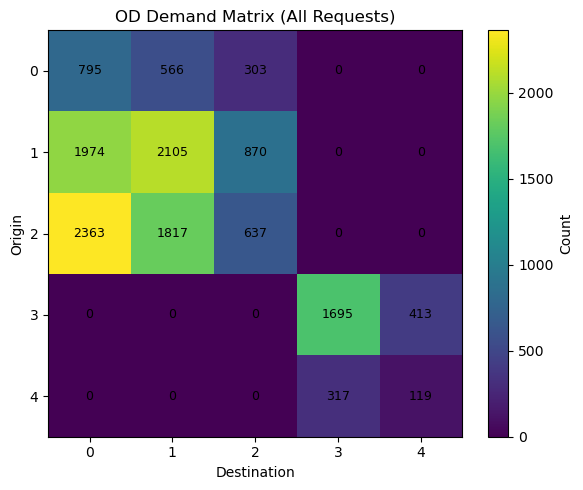

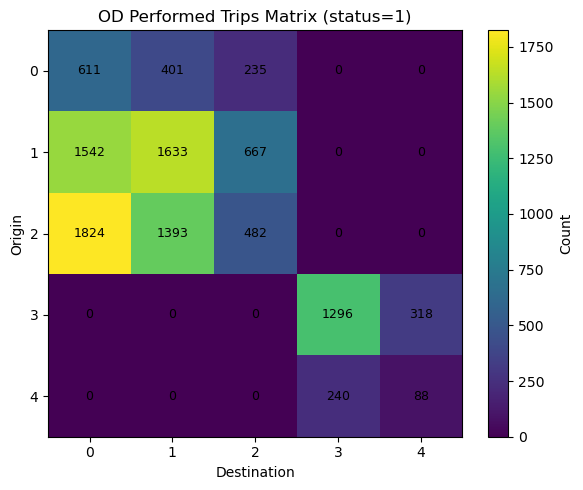

In [88]:
def plot_od_matrix(mat, title):
    plt.figure(figsize=(6,5))
    plt.imshow(mat, aspect='auto')
    plt.colorbar(label='Count')
    plt.title(title)
    plt.xlabel('Destination')
    plt.ylabel('Origin')
    plt.xticks(range(mat.shape[1]), mat.columns)
    plt.yticks(range(mat.shape[0]), mat.index)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            plt.text(j,i,int(mat.iloc[i,j]),ha='center',va='center',fontsize=9)
    plt.tight_layout()
    plt.show()

plot_od_matrix(demand_mat, "OD Demand Matrix (All Requests)")
plot_od_matrix(performed_mat, "OD Performed Trips Matrix (status=1)")

### 2) درصد تقاضای برآورده نشده (status=4)
- درصد کلی و تغییرات ساعتی
- پرتکرارترین OD از نظر سهم تقاضا
- OD با بیشترین نوسان قیمت به ازای کیلومتر
- مقایسه نسبت تخفیف در ساعات پیک و غیرپیک

Overall unmet demand rate: 1.95%


,unmet_rate
hour,
0.0,0.020833
1.0,0.022727
2.0,0.058824
3.0,0.000000
4.0,0.000000
5.0,0.096774
6.0,0.021053
7.0,0.014019
8.0,0.020755


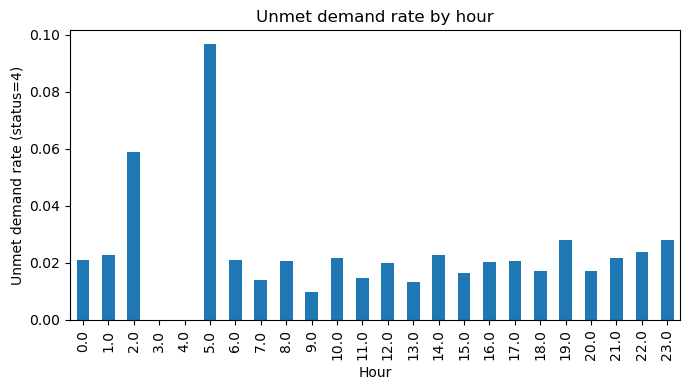

In [89]:
unmet_overall = (df_clean['status'] == 4).mean()

unmet_by_hour = (
    (df_clean['status'] == 4)
    .groupby(df_clean['hour'])
    .mean()
    .sort_index()
)

print(f"Overall unmet demand rate: {unmet_overall*100:.2f}%")
display(unmet_by_hour.to_frame('unmet_rate'))

plt.figure(figsize=(7,4))
unmet_by_hour.plot(kind='bar')
plt.ylabel('Unmet demand rate (status=4)')
plt.xlabel('Hour')
plt.title('Unmet demand rate by hour')
plt.tight_layout()
plt.show()

In [90]:
od_counts = df_clean.groupby(['origin','destination']).size()
total = len(df_clean)

top5 = (od_counts.sort_values(ascending=False)
        .head(5)
        .div(total)
        .mul(100)
        .round(2)
        .reset_index(name='demand_share_percent'))

display(top5)

,origin,destination,demand_share_percent
0,2,0,16.91
1,1,1,15.06
2,1,0,14.13
3,2,1,13.00
4,3,3,12.13


In [91]:
# Price per km volatility by OD (std)
ppk_stats = df_clean.groupby(['origin','destination'])['price_per_km'].agg(['mean','std','count'])
ppk_stats = ppk_stats[ppk_stats['count']>=30].sort_values('std', ascending=False)
display(ppk_stats.head(10))

mean          std  count
origin destination                                  
0      2            18333.778500  6864.720419    303
4      4            22161.373717  6603.011056    119
3      3            16800.771437  6015.266765   1695
1      0            22628.194398  5647.243404   1974
2      1            18484.582466  5616.039266   1817
0      0            17271.728404  5579.438134    795
1      2            16870.629201  5335.905957    870
       1            17623.600340  4750.147073   2105
4      3            14872.464987  4656.589062    317
3      4            13695.862768  4524.454502    413

In [92]:
peak_mask = df_clean['hour'].isin([6,7,8,16,17,18,19])
peak_ratio = df_clean.loc[peak_mask,'discount_ratio'].mean()*100
off_ratio = df_clean.loc[~peak_mask,'discount_ratio'].mean()*100
print(f"Peak hours discount/price ratio: {peak_ratio:.2f}%")
print(f"Off-peak discount/price ratio: {off_ratio:.2f}%")

Peak hours discount/price ratio: 15.68%
Off-peak discount/price ratio: 15.05%


### 3) تحلیل زمانی
- توزیع تعداد درخواست‌ها در ساعات مختلف
- سطح و نوسانات قیمت در ساعات مختلف

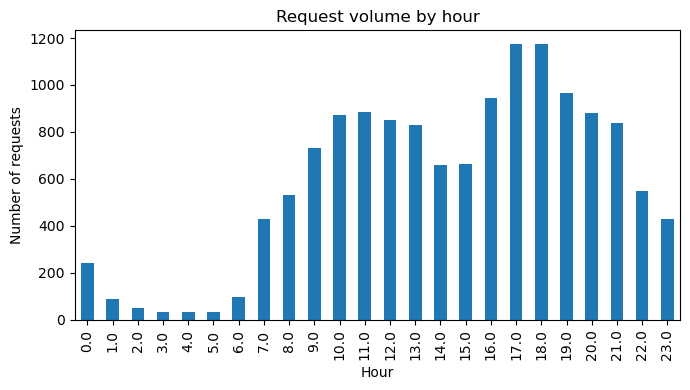

Most requests hour: 18 count: 1174
Least requests hour: 5 count: 31


In [93]:
counts_by_hour = df_clean.groupby('hour').size().sort_index()
plt.figure(figsize=(7,4))
counts_by_hour.plot(kind='bar')
plt.ylabel('Number of requests')
plt.xlabel('Hour')
plt.title('Request volume by hour')
plt.tight_layout()
plt.show()

print("Most requests hour:", int(counts_by_hour.idxmax()), "count:", int(counts_by_hour.max()))
print("Least requests hour:", int(counts_by_hour.idxmin()), "count:", int(counts_by_hour.min()))

,mean,std,count
hour,,,
0.0,70500.000000,14309.782475,240
1.0,69602.272727,10991.678956,88
2.0,67745.098039,9290.518042,51
3.0,67857.142857,8513.459438,35
4.0,69714.285714,11753.776436,35
5.0,72258.064516,11535.359384,31
6.0,58315.789474,12129.849903,95
7.0,53025.700935,12065.076985,428
8.0,51471.698113,12820.711878,530


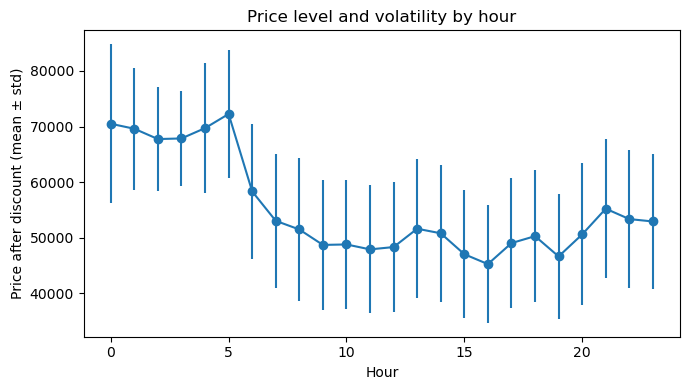

In [94]:
price_by_hour = df_clean.groupby('hour')['price_after_discount'].agg(['mean','std','count']).sort_index()
display(price_by_hour)

plt.figure(figsize=(7,4))
plt.errorbar(price_by_hour.index, price_by_hour['mean'], yerr=price_by_hour['std'], fmt='o-')
plt.xlabel('Hour')
plt.ylabel('Price after discount (mean ± std)')
plt.title('Price level and volatility by hour')
plt.tight_layout()
plt.show()

### 4) تحلیل کنسلی‌ها و وضعیت‌ها در ساعات مختلف

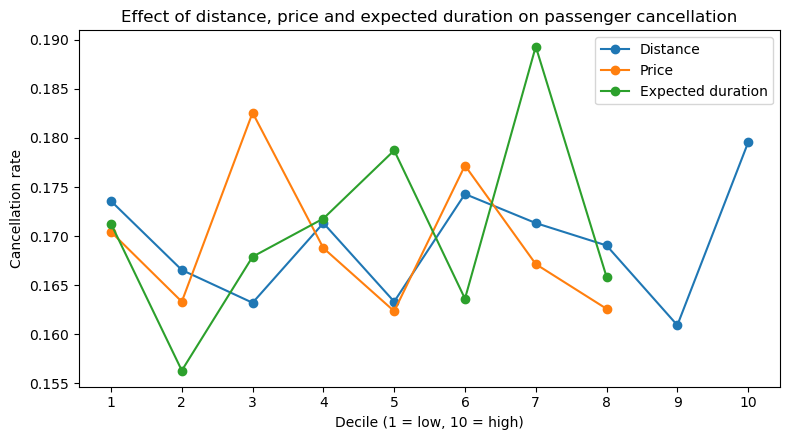

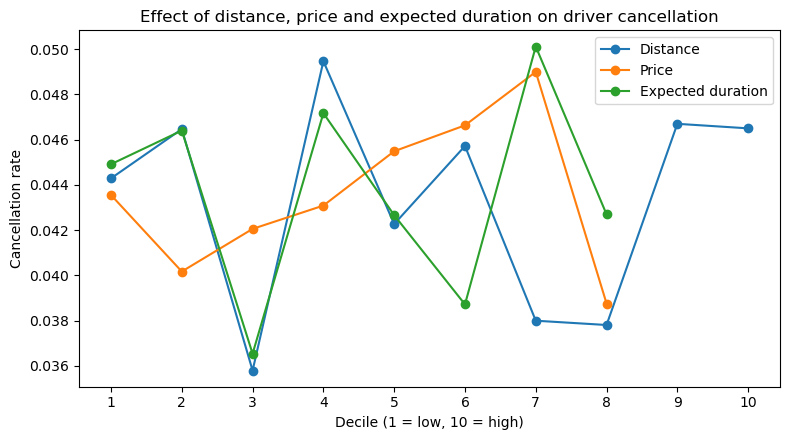

In [95]:
# Cancellation analysis (ONE plot per side)

def plot_cancel_effects(df, cancel_status, title):
    d = df.copy()

    # 1) cancellation flag
    d["is_cancel"] = (d["status"] == cancel_status)

    # 2) decile binning for each factor
    d["dist_dec"] = pd.qcut(d["distance_km"], 10, labels=False, duplicates="drop") + 1
    d["price_dec"] = pd.qcut(d["price_after_discount"], 10, labels=False, duplicates="drop") + 1
    d["dur_dec"] = pd.qcut(d["expected_duration"], 10, labels=False, duplicates="drop") + 1

    # 3) cancellation rate per decile
    dist_rate = d.groupby("dist_dec", observed=True)["is_cancel"].mean()
    price_rate = d.groupby("price_dec", observed=True)["is_cancel"].mean()
    dur_rate = d.groupby("dur_dec", observed=True)["is_cancel"].mean()

    # unify x-axis (1..10)
    x = np.arange(1, 11)
    dist_rate = dist_rate.reindex(x)
    price_rate = price_rate.reindex(x)
    dur_rate = dur_rate.reindex(x)

    # 4) plot (single 2D plot, three lines)
    plt.figure(figsize=(8, 4.5))
    plt.plot(x, dist_rate, marker="o", label="Distance")
    plt.plot(x, price_rate, marker="o", label="Price")
    plt.plot(x, dur_rate, marker="o", label="Expected duration")

    plt.xticks(x)
    plt.xlabel("Decile (1 = low, 10 = high)")
    plt.ylabel("Cancellation rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Passenger cancellation (status = 2)

plot_cancel_effects(
    df_clean,
    cancel_status=2,
    title="Effect of distance, price and expected duration on passenger cancellation"
)


# Driver cancellation (status = 3)

plot_cancel_effects(
    df_clean,
    cancel_status=3,
    title="Effect of distance, price and expected duration on driver cancellation"
)